## Quantum error correction with dynamic circuits

Quantum error correction (QEC) is the key ingredient for scaling quantum computers beyond the reach of today's noisy hardware. Unlike the *error mitigation* techniques covered elsewhere in these examples, which post-process results to reduce bias, QEC *actively* detects and repairs errors while a computation is still running. This requires exactly the tools that dynamic circuits provide: mid-circuit measurements (MCM) to read out error information, and feedforward (FF) to apply corrections conditioned on those measurements in real time.

In this notebook we implement the smallest complete QEC code, the three-qubit bit-flip code, on Amazon Braket. We will:

1. Encode a logical qubit across three physical qubits.
2. Extract an error *syndrome* with ancilla qubits and mid-circuit measurements, without disturbing the encoded information.
3. Decode the syndrome and apply a real-time feedforward correction, respecting the hardware constraint that each feedback target listens to a single measurement source.
4. Quantify the protection with a noise sweep, and run a hardware-compatible variant on IQM Garnet.

This notebook builds on the concepts in the [introduction to dynamic circuits](0_Intro_to_Dynamic_Circuits_on_IQM.ipynb), the [dynamic circuit constructions](1_Dynamic_Circuit_Constructions.ipynb), and [handling noise with dynamic circuits](2_Handling_Noise_with_Dynamic_Circuits.ipynb).

### The three-qubit bit-flip code

A single physical qubit that suffers a bit-flip error $X$ has no redundancy, so the error is undetectable and uncorrectable. The bit-flip code spreads one *logical* qubit across three *physical* qubits by encoding

$$ |0\rangle_L = |000\rangle, \qquad |1\rangle_L = |111\rangle, $$

so that a general logical state $\alpha|0\rangle_L + \beta|1\rangle_L = \alpha|000\rangle + \beta|111\rangle$. We prepare this with two CNOTs fanning out from the data qubit.

To detect a bit-flip we measure two *stabilizers*, $Z_0 Z_1$ and $Z_1 Z_2$. These are parity checks: each reports whether a neighbouring pair of qubits agrees, and crucially they commute with the logical operators, so measuring them reveals *where an error occurred* without collapsing the logical superposition. Using one ancilla per parity check, the pair of measurement outcomes $(s_{01}, s_{12})$ forms the **syndrome**:

| Error location | $s_{01}=Z_0Z_1$ | $s_{12}=Z_1Z_2$ | syndrome |
|---|---|---|---|
| none | 0 | 0 | `00` |
| qubit 0 | 1 | 0 | `10` |
| qubit 1 | 1 | 1 | `11` |
| qubit 2 | 0 | 1 | `01` |

Each single-qubit bit-flip produces a unique syndrome, so we can correct it by applying an $X$ to the flagged qubit. Notice that the middle qubit is flagged only when *both* parities fire, `11`. That "both" condition is the one subtlety we have to engineer around on hardware, as we will see.

### Notebook setup

We import the dynamic-circuit primitives and, as in the other notebooks in this series, `iqm_config`, which registers the IQM-native Clifford subroutines together with the `cc_x` / `cc_z` classically conditioned gates. The same circuits run on either IQM Garnet or the local Braket density matrix simulator (`braket_dm`), which supports the `measure_ff` and `cc_prx` primitives directly. Set the `use_qpu` flag to switch between the two.

In [1]:
from math import cos, pi

import matplotlib.pyplot as plt
import numpy as np

from braket.circuits import Circuit
from braket.experimental_capabilities import EnableExperimentalCapability
from braket.tracking import Tracker

In [2]:
import iqm_config  # noqa: F401  (registers IQM-native gates and cc_x / cc_z subroutines)

from braket.aws import AwsDevice
from braket.devices import LocalSimulator
from braket.devices.devices import Devices

use_qpu = False

qd = AwsDevice(Devices.IQM.Garnet) if use_qpu else LocalSimulator("braket_dm")

track = Tracker().start()


def logical_error(counts: dict, agree_state: str = "0") -> float:
    # fraction of shots where the decoded logical qubit is flipped
    shots = sum(counts.values())
    return sum(v for k, v in counts.items() if k[0] != agree_state) / shots

### Detecting errors: syndrome extraction

We first build the encoder and the syndrome-extraction block, then read the two ancillas directly to confirm the syndrome table above. We use six qubits: three data qubits (`D0, D1, D2`), two syndrome ancillas (`A01, A12`), and one extra ancilla (`AMID`) that we will use for decoding in the next section.

The `inject_error` helper lets us deterministically place an $X$ error on any data qubit so we can inspect the response of the code. On real hardware these errors arise from the environment; here we insert them by hand to characterize the code.

In [3]:
D0, D1, D2 = 0, 1, 2  # data qubits
A01, A12, AMID = 3, 4, 5  # syndrome ancillas + "middle" flag ancilla


def encode(circ, theta=0.0):
    # prepare (cos(theta/2)|0> + sin(theta/2)|1>)_L = cos|000> + sin|111>
    circ.ry(D0, theta)
    circ.cnot(D0, D1)
    circ.cnot(D0, D2)


def inject_error(circ, loc):
    # insert a bit-flip on data qubit `loc` (or no error if loc is None)
    if loc is not None:
        circ.x(loc)


def extract_syndrome(circ):
    # compute Z0Z1 parity onto A01 and Z1Z2 parity onto A12
    circ.cnot(D0, A01)
    circ.cnot(D1, A01)
    circ.cnot(D1, A12)
    circ.cnot(D2, A12)

In [4]:
labels = {None: "no error", D0: "X on qubit 0", D1: "X on qubit 1", D2: "X on qubit 2"}
syndromes = {}

for loc in [None, D0, D1, D2]:
    with EnableExperimentalCapability():
        circ = Circuit()
        encode(circ, theta=pi / 3)
        inject_error(circ, loc)
        extract_syndrome(circ)
        if use_qpu:
            circ = Circuit().add_verbatim_box(circ)
        circ.measure([A01, A12])
    counts = qd.run(circ, shots=500).result().measurement_counts
    syndromes[loc] = max(counts, key=counts.get)
    print(f"{labels[loc]:>14}:  syndrome = {syndromes[loc]}   {dict(counts)}")

/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/braket/experimental_capabilities/experimental_capability_context.py:126: UserWarning: You are enabling experimental capabilities. To view descriptions and restrictions of experimental capabilities, please review Amazon Braket Developer Guide (https://docs.aws.amazon.com/braket/latest/developerguide/braket-experimental-capabilities.html).
  warnings.warn(
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/braket/default_simulator/simulator.py:345: UserWarning: You are running a noise-free circuit on the density matrix simulator. Consider running this circuit on the state vector simulator: LocalSimulator("default") for a better user experience.
  warnings.warn(


      no error:  syndrome = 00   {'00': 500}
  X on qubit 0:  syndrome = 10   {'10': 500}
  X on qubit 1:  syndrome = 11   {'11': 500}
  X on qubit 2:  syndrome = 01   {'01': 500}


/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/braket/experimental_capabilities/experimental_capability_context.py:126: UserWarning: You are enabling experimental capabilities. To view descriptions and restrictions of experimental capabilities, please review Amazon Braket Developer Guide (https://docs.aws.amazon.com/braket/latest/developerguide/braket-experimental-capabilities.html).
  warnings.warn(
/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/braket/default_simulator/simulator.py:345: UserWarning: You are running a noise-free circuit on the density matrix simulator. Consider running this circuit on the state vector simulator: LocalSimulator("default") for a better user experience.
  warnings.warn(


The measured syndromes match the table exactly: `00`, `10`, `11`, `01` for no error and errors on qubits 0, 1, and 2. The code has *detected* which qubit flipped, and because the parity checks commute with the logical operators, it has done so without measuring the logical state itself.

### Correcting errors in real time with feedforward

Detection is only half the story. To *correct* the error while the qubits are still coherent we feed the syndrome forward into a conditional $X$ gate. On Braket this is `measure_ff` (mid-circuit measurement into a classical register) followed by `cc_prx`, which applies a phased-$X$ rotation conditioned on that register; `cc_prx(q, pi, 0, key)` is a classically conditioned $X$.

Here we hit the hardware constraint noted in the [introduction notebook](0_Intro_to_Dynamic_Circuits_on_IQM.ipynb): **each feedback target can listen to only one measurement source.** The edge qubits are fine, qubit 0 is corrected from $s_{01}$ and qubit 2 from $s_{12}$, but the middle qubit needs *both* syndrome bits (`11`), which a single `cc_prx` cannot express.

We solve this with a small **one-hot decoder** applied *before* measurement. A Toffoli writes the logical AND of the two parities into `AMID`, and two CNOTs then strip that shared contribution back out of `A01` and `A12`:

```
AMID = A01 AND A12      # fires only for a middle-qubit error
A01  = A01 XOR AMID     # now fires only for a qubit-0 error
A12  = A12 XOR AMID     # now fires only for a qubit-2 error
```

After decoding, the three ancillas hold a **one-hot** flag, at most one is set, pointing directly at the qubit to fix. Each data qubit is now corrected from a single source, satisfying the hardware constraint while implementing the full code.

In [5]:
def onehot_decode(circ):
    # map the 2-bit syndrome to one-hot flags: A01->q0, A12->q2, AMID->q1
    circ.ccnot(A01, A12, AMID)  # AMID = A01 AND A12  (middle-qubit error)
    circ.cnot(AMID, A01)  # remove the shared middle contribution
    circ.cnot(AMID, A12)


def correct(circ):
    # feedforward correction; each data qubit listens to a single ancilla
    circ.measure_ff(A01, 0)
    circ.cc_prx(D0, pi, 0.0, 0)  # X on qubit 0 if flagged
    circ.measure_ff(A12, 1)
    circ.cc_prx(D2, pi, 0.0, 1)  # X on qubit 2 if flagged
    circ.measure_ff(AMID, 2)
    circ.cc_prx(D1, pi, 0.0, 2)  # X on qubit 1 if flagged

We now assemble the full protocol: encode a logical state at angle $\theta$, inject an error, extract and decode the syndrome, correct with feedforward, then *decode* (invert the encoder) and read the logical qubit off `D0`. For a correctly protected state the measured population of `D0` should equal the ideal value $\cos^2(\theta/2)$ regardless of where the error landed.

In [6]:
theta = pi / 3
ideal_p0 = cos(theta / 2) ** 2

corrected_p0 = {}
for loc in [None, D0, D1, D2]:
    with EnableExperimentalCapability():
        circ = Circuit()
        encode(circ, theta)
        inject_error(circ, loc)
        extract_syndrome(circ)
        onehot_decode(circ)
        correct(circ)
        circ.cnot(D0, D1)  # decode (invert the encoder)
        circ.cnot(D0, D2)
        if use_qpu:
            circ = Circuit().add_verbatim_box(circ)
        circ.measure([D0])
    counts = qd.run(circ, shots=500).result().measurement_counts
    corrected_p0[loc] = counts.get("0", 0) / sum(counts.values())
    print(f"{labels[loc]:>14}:  P(logical=0) = {corrected_p0[loc]:.3f}   (ideal {ideal_p0:.3f})")

      no error:  P(logical=0) = 0.750   (ideal 0.750)
  X on qubit 0:  P(logical=0) = 0.758   (ideal 0.750)
  X on qubit 1:  P(logical=0) = 0.722   (ideal 0.750)


/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/braket/experimental_capabilities/experimental_capability_context.py:126: UserWarning: You are enabling experimental capabilities. To view descriptions and restrictions of experimental capabilities, please review Amazon Braket Developer Guide (https://docs.aws.amazon.com/braket/latest/developerguide/braket-experimental-capabilities.html).
  warnings.warn(


  X on qubit 2:  P(logical=0) = 0.796   (ideal 0.750)


Every error location recovers the ideal logical population, the code has actively corrected a bit-flip on any one of the three qubits. Because the correction is coherent and driven by stabilizer measurements that never touch the logical information, superpositions are preserved too: a logical $|+\rangle_L$ stays a $|+\rangle_L$. You can verify this by replacing the `ry(D0, theta)` preparation with a Hadamard and measuring in the logical $X$ basis (apply a Hadamard to `D0` after decoding); the outcome remains `0` with near-certainty for an error on any qubit.

### How much does the code help?

A QEC code is only useful if correcting errors leaves us better off than not encoding at all. The bit-flip code corrects *any single* bit-flip, so it only fails when *two or more* qubits flip. If each qubit independently flips with probability $p$, the logical failure rate scales as $\mathcal{O}(p^2)$, a quadratic suppression, versus the linear $p$ of an unprotected qubit. Below the break-even point the encoded qubit is more reliable.

We demonstrate this on the simulator by applying a depolarizing channel of strength $p$ to each data qubit after encoding, then comparing the logical error rate with and without the feedforward correction. (Depolarizing noise also contains phase errors, which the bit-flip code does not correct, but those do not affect a logical $Z$-basis readout.)

In [7]:
sim = LocalSimulator("braket_dm")
ps = np.linspace(0.0, 0.5, 11)
uncorrected, corrected = [], []

for p in ps:
    row = {}
    for do_correct in (False, True):
        with EnableExperimentalCapability():
            circ = Circuit()
            encode(circ, theta=0.0)  # logical |0>
            for q in (D0, D1, D2):
                circ.depolarizing(q, p)
            if do_correct:
                extract_syndrome(circ)
                onehot_decode(circ)
                correct(circ)
            circ.cnot(D0, D1)  # decode
            circ.cnot(D0, D2)
            circ.measure([D0])
        counts = sim.run(circ, shots=2000).result().measurement_counts
        row[do_correct] = logical_error(counts)
    uncorrected.append(row[False])
    corrected.append(row[True])
    print(f"p = {p:.2f}:  uncorrected = {row[False]:.4f}   corrected = {row[True]:.4f}")

/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/braket/experimental_capabilities/experimental_capability_context.py:126: UserWarning: You are enabling experimental capabilities. To view descriptions and restrictions of experimental capabilities, please review Amazon Braket Developer Guide (https://docs.aws.amazon.com/braket/latest/developerguide/braket-experimental-capabilities.html).
  warnings.warn(


p = 0.00:  uncorrected = 0.0000   corrected = 0.0000
p = 0.05:  uncorrected = 0.0335   corrected = 0.0020
p = 0.10:  uncorrected = 0.0705   corrected = 0.0155
p = 0.15:  uncorrected = 0.1015   corrected = 0.0305
p = 0.20:  uncorrected = 0.1210   corrected = 0.0525
p = 0.25:  uncorrected = 0.1760   corrected = 0.0820
p = 0.30:  uncorrected = 0.2075   corrected = 0.0930
p = 0.35:  uncorrected = 0.2290   corrected = 0.1375
p = 0.40:  uncorrected = 0.2585   corrected = 0.1775
p = 0.45:  uncorrected = 0.2955   corrected = 0.2035
p = 0.50:  uncorrected = 0.3290   corrected = 0.2655


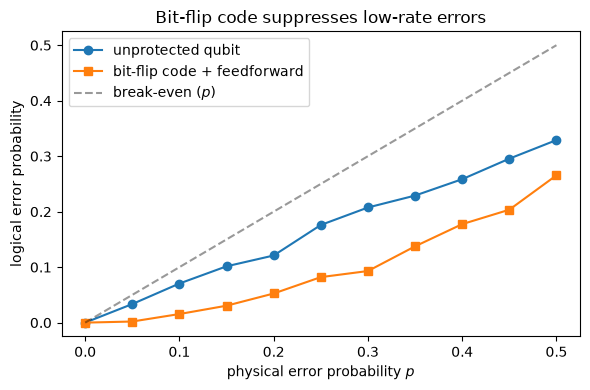

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(ps, uncorrected, "o-", label="unprotected qubit")
plt.plot(ps, corrected, "s-", label="bit-flip code + feedforward")
plt.plot(ps, ps, "k--", alpha=0.4, label="break-even ($p$)")
plt.xlabel("physical error probability $p$")
plt.ylabel("logical error probability")
plt.title("Bit-flip code suppresses low-rate errors")
plt.legend()
plt.tight_layout()
plt.show()

For small $p$ the corrected curve drops well below the unprotected line, the hallmark quadratic suppression of a distance-3 code. As $p$ grows the two curves approach each other and eventually cross: once errors are common enough that double-flips are likely, encoding no longer helps. This crossover is a miniature version of the *threshold* behaviour that underpins fault-tolerant quantum computing.

### Running on IQM Garnet

The full six-qubit protocol above uses a Toffoli in the decoder and all-to-all interactions between the data and ancilla qubits, which require transpilation to IQM-native gates and a qubit layout matching Garnet's connectivity (see the notes in the [introduction notebook](0_Intro_to_Dynamic_Circuits_on_IQM.ipynb)). For a compact demonstration that runs directly on hardware, we use a single reusable ancilla to perform a parity check between two data qubits and correct one of them in real time with `cc_x`, the same feedforward primitive, now within Garnet's single-source constraint.

We prepare a parity-even state on two data qubits, optionally inject a bit-flip, and compare the outcome with and without an active correction round. Set `use_qpu = True` at the top of the notebook to run this on Garnet; on hardware, choose a connected triple of qubits from a single group of the device layout.

In [9]:
qreg = [0, 1, 2]  # data, ancilla (middle), data  -> map to connected Garnet qubits on hardware

for inject in (False, True):
    outcome = {}
    for do_correct in (False, True):
        with EnableExperimentalCapability():
            circ = Circuit()
            circ.h(qreg[0])
            circ.h(qreg[2])
            circ.h(qreg[1])
            circ.cz(qreg[0], qreg[1])
            circ.cz(qreg[2], qreg[1])
            circ.h(qreg[1])
            circ.cc_x([qreg[1], qreg[2]])  # prepare parity-even logical state
            if inject:
                circ.x(qreg[0])  # bit-flip error
            if do_correct:
                circ.h(qreg[1])
                circ.cz(qreg[0], qreg[1])
                circ.cz(qreg[2], qreg[1])
                circ.h(qreg[1])
                circ.cc_x([qreg[1], qreg[2]])  # parity re-check + feedforward correction
            if use_qpu:
                circ = Circuit().add_verbatim_box(circ)
            circ.measure([qreg[0], qreg[2]])
        counts = qd.run(circ, shots=500).result().measurement_counts
        shots = sum(counts.values())
        # a bit-flip breaks the even parity of the two data qubits
        outcome[do_correct] = sum(v for k, v in counts.items() if k[0] != k[1]) / shots
    tag = "bit-flip injected" if inject else "no error"
    print(
        f"{tag:>18}:  parity error uncorrected = {outcome[False]:.3f}   corrected = {outcome[True]:.3f}"
    )

          no error:  parity error uncorrected = 0.000   corrected = 0.000
 bit-flip injected:  parity error uncorrected = 1.000   corrected = 0.000


Without a correction round an injected bit-flip breaks the parity and shows up as an error; with the feedforward round the parity is restored and the error returns to zero. This single-ancilla pattern is the hardware-friendly building block that the full six-qubit code generalizes.

### Predicted costs

The local simulator examples run at no cost. If you enable `use_qpu`, the estimated IQM Garnet cost is reported below.

In [10]:
print("Quantum Task Summary")
print(track.quantum_tasks_statistics())
print(
    "\nNote: Charges shown are estimates based on your Amazon Braket simulator and quantum processing unit (QPU) task usage.\nEstimated charges shown may differ from your actual charges. Estimated charges do not factor in any discounts or credits,\nand you may experience additional charges based on your use of other services such as Amazon Elastic Compute Cloud (Amazon EC2).",
)
print(
    f"\nEstimated cost to run this example: {track.qpu_tasks_cost() + track.simulator_tasks_cost():.3f} USD",
)

Quantum Task Summary
{}

Note: Charges shown are estimates based on your Amazon Braket simulator and quantum processing unit (QPU) task usage.
Estimated charges shown may differ from your actual charges. Estimated charges do not factor in any discounts or credits,
and you may experience additional charges based on your use of other services such as Amazon Elastic Compute Cloud (Amazon EC2).

Estimated cost to run this example: 0.000 USD


### Conclusions

In this notebook we implemented the three-qubit bit-flip code, the smallest complete quantum error correction code, using dynamic circuits on Amazon Braket. Mid-circuit measurements extracted an error syndrome without disturbing the logical state, and a one-hot decoder let us apply a real-time feedforward correction while respecting the single-source feedback constraint of IQM Garnet. A noise sweep confirmed the code's quadratic suppression of low-rate errors, and a compact single-ancilla variant demonstrated the same feedforward correction on hardware.

The bit-flip code only protects against $X$ errors; correcting arbitrary errors requires codes such as the phase-flip code (the bit-flip code conjugated by Hadamards), the nine-qubit Shor code that combines both, or the surface codes at the heart of modern fault-tolerant architectures. Each of these is built from the same primitives shown here, repeated syndrome extraction and feedforward correction, making dynamic circuits an essential tool on the path to fault tolerance.

### References
1. Nielsen, Chuang. *Quantum Computation and Quantum Information*. (2010) Cambridge University Press.
2. Shor. *Scheme for reducing decoherence in quantum computer memory*. (1995) [Phys. Rev. A 52, R2493](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.52.R2493).
3. Corcoles, Takita, Inoue et al. *Exploiting dynamic quantum circuits in a quantum algorithm with superconducting qubits*. (2021) [Phys. Rev. Lett. 127, 100501](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.127.100501), [arXiv:2102.01682](https://arxiv.org/pdf/2102.01682).
4. Google Quantum AI. *Quantum error correction below the surface code threshold*. (2024) [Nature 638, 920](https://www.nature.com/articles/s41586-024-08449-y).
5. Explore experimental capabilities. *Amazon Braket Developer Guide* https://docs.aws.amazon.com/braket/latest/developerguide/braket-experimental-capabilities.html